In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import numpy as np 
import pandas as pd
import datetime
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar
from zhiyi.analysis.SE_analysis import get_site_index 
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree
import datetime as dt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
print("done")

done


In [ ]:

# SCRIP
SCRIP_file = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
SCRIP_file_ne60 ="/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc"

filebase_ne30 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/'
                 'MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc')
filebase_ne60 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/'
                 'MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc')

start_date = datetime.date(2018, 5, 22)
end_date   = datetime.date(2018, 6, 15)

city_lonlat = {
    'London':    [360 - 0.213492,  51.521050],
    'Manchester':[360 - 2.237881, 53.481520],
    # 'Edingurgh': [360 - 3.182186, 55.945589],
    'Glasgow':   [360 - 4.259122, 55.858940],
    'Birmingham': [360 - 1.874978, 52.476145],
    # 'Belfast':   [360 - 5.9301, 54.5973],
    # 'Glasgow':   [360 - 4.2576, 55.8651],
    # 'Bristol':   [360 - 2.5879, 51.4545],
}

In [ ]:
def collect_files(template, start, end):
    files = []
    cur = start
    while cur <= end:
        f = (template
             .replace("MM", cur.strftime("%m"))
             .replace("DD", cur.strftime("%d")))
        if os.path.exists(f):
            files.append(f)
        else:
            print(f"Warning: File not found - {f}, skipping.")
        cur += datetime.timedelta(days=1)
    return files

def get_obs_series(obs_df, station_to_col, station, start, end):
    col = station_to_col[station]
    s = pd.to_numeric(obs_df[col], errors='coerce') 
    return s[start:end]

def build_kdtree(ds):
    lon360 = ds['lon'].isel(time=0).values
    lat    = ds['lat'].isel(time=0).values
    lon180 = (lon360 + 180) % 360 - 180
    tree   = cKDTree(np.vstack([lat, lon180]).T)
    return tree, lon360, lat, lon180

def get_3x3_minmax(ds, tree, lon180_all, city_lon, city_lat, k=9):
    lon180_c = (city_lon + 180) % 360 - 180
    _, idx9  = tree.query([city_lat, lon180_c], k=k)
    pm9 = ds['O3'][:, -1, idx9].values * 1e9
    return np.nanmin(pm9, axis=1), np.nanmax(pm9, axis=1)

scrip30 = xr.open_dataset(SCRIP_file)
scrip60 = xr.open_dataset(SCRIP_file_ne60)

se_files_30 = collect_files(filebase_ne30, start_date, end_date)
se_files_60 = collect_files(filebase_ne60, start_date, end_date)

ds_ne30 = xr.open_mfdataset(se_files_30, combine="by_coords")
ds_ne60 = xr.open_mfdataset(se_files_60, combine="by_coords")

print("Datasets loaded!")

Datasets loaded!


In [ ]:
Index_lonlat_30 = {}
Index_lonlat_60 = {}

for city, (lon360_c, lat_c) in city_lonlat.items():
    Index_lonlat_30[city] = get_site_index(
        lon360_c, lat_c,
        scrip_file=SCRIP_file
    )
    Index_lonlat_60[city] = get_site_index(
        lon360_c, lat_c,
        scrip_file=SCRIP_file_ne60
    )

TS     = {}
TS_f09 = {}
for city in city_lonlat:
    idx30 = Index_lonlat_30[city]
    idx60 = Index_lonlat_60[city]
    TS[city]     = ds_ne30['O3'].values[:, -1, idx30] * 1e9
    TS_f09[city] = ds_ne60['O3'].values[:, -1, idx60] * 1e9

time_values      = pd.to_datetime(ds_ne30.time.values)
time_values_nobb = pd.to_datetime(ds_ne60.time.values)

tree_30, lon360_30, lat_30, lon180_30 = build_kdtree(ds_ne30)
tree_60, lon360_60, lat_60, lon180_60 = build_kdtree(ds_ne60)

pm_min_30   = {}
pm_max_30   = {}
pm_min_60   = {}
pm_max_60   = {}
for city, (lon_c, lat_c) in city_lonlat.items():
    mn30, mx30 = get_3x3_minmax(
        ds_ne30, tree_30, lon180_30, lon_c, lat_c, k=36)
    mn60, mx60 = get_3x3_minmax(
        ds_ne60, tree_60, lon180_60, lon_c, lat_c, k=2)
    pm_min_30[city], pm_max_30[city] = mn30, mx30
    pm_min_60[city], pm_max_60[city] = mn60, mx60


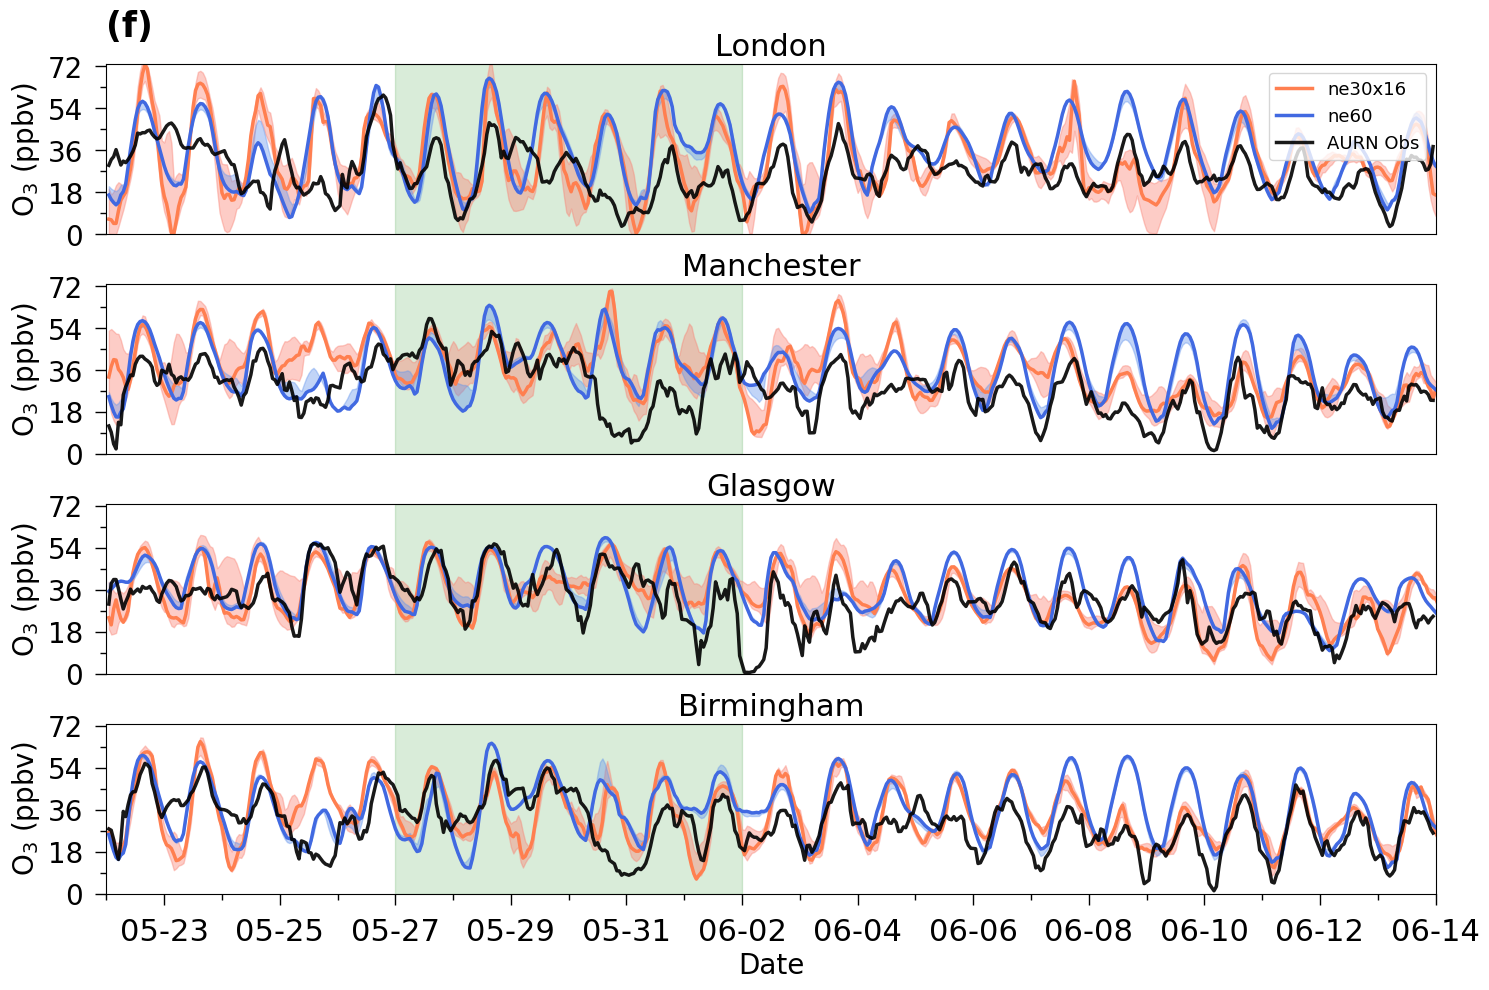

In [ ]:
cities = list(city_lonlat.keys())
fig, axes = plt.subplots(4, 1, figsize=(15, 10))
day_locator   = mdates.DayLocator(interval=1)
day_formatter = mdates.DateFormatter('%m-%d')

obs = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/london_o3.csv')
obs['Date'] = pd.to_datetime(obs['Date'].astype(str) + ' ' + obs['Time'].astype(str), errors='coerce')
ycol = 'average'
start_date = pd.to_datetime('2018-05-22')
end_date   = pd.to_datetime('2018-06-14')
obs_sel = obs[(obs['Date'] >= start_date) & (obs['Date'] <= end_date)].sort_values('Date')

obs_man = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/manchester_o3.csv')
obs_man['Date'] = pd.to_datetime(obs_man['Date'].astype(str) + ' ' + obs_man['Time'].astype(str), errors='coerce')
ycol = 'average'
start_date = pd.to_datetime('2018-05-22')
end_date   = pd.to_datetime('2018-06-14')
obs_sel_man = obs_man[(obs_man['Date'] >= start_date) & (obs_man['Date'] <= end_date)].sort_values('Date')

obs_gla = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/glasgow_o3.csv')
obs_gla['Date'] = pd.to_datetime(obs_gla['Date'].astype(str) + ' ' + obs_gla['Time'].astype(str), errors='coerce')
ycol = 'average'
start_date = pd.to_datetime('2018-05-22')
end_date   = pd.to_datetime('2018-06-14')
obs_sel_gla = obs_gla[(obs_gla['Date'] >= start_date) & (obs_gla['Date'] <= end_date)].sort_values('Date')

obs_bir = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/birmingham_o3.csv')
obs_bir['Date'] = pd.to_datetime(obs_bir['Date'].astype(str) + ' ' + obs_bir['Time'].astype(str), errors='coerce')
ycol = 'average'
start_date = pd.to_datetime('2018-05-22')
end_date   = pd.to_datetime('2018-06-14')
obs_sel_bir = obs_bir[(obs_bir['Date'] >= start_date) & (obs_bir['Date'] <= end_date)].sort_values('Date')

time_values_bst = (pd.to_datetime(time_values.astype('datetime64[ns]'))
                   .tz_localize('UTC')
                   .tz_convert('Europe/London'))
time_values_nobb_bst = (pd.to_datetime(time_values_nobb.astype('datetime64[ns]'))
                        .tz_localize('UTC')
                        .tz_convert('Europe/London'))

for i, city in enumerate(cities):
    ax = axes[i]
    ax.fill_between(time_values_bst,      pm_min_30[city], pm_max_30[city], alpha=0.4 , color='salmon')
    ax.plot(time_values_bst,      TS[city].squeeze(),    color='coral', linewidth=2.5, label='ne30x16')   
    ax.fill_between(time_values_nobb_bst, pm_min_60[city], pm_max_60[city], alpha=0.4,color='cornflowerblue')
    ax.plot(time_values_nobb_bst, TS_f09[city].squeeze(), color='royalblue', linewidth=2.5, label='ne60')
    
    ax.axvspan(pd.to_datetime('2018-05-27'), pd.to_datetime('2018-06-02'),
            color='green', alpha=0.15, zorder=0)
    
    if i == 0:
        ax.plot(
            obs_sel['Date'], obs_sel[ycol] * 0.5033,
            color='black', linewidth=2.5, alpha=0.9,
            label='AURN Obs'
        )
        ax.legend(fontsize=20, loc='upper right')
    elif i == 1:  
        ax.plot(
            obs_sel_man['Date'], obs_sel_man[ycol] * 0.5007,
            color='black', linewidth=2.5, alpha=0.9,
            label='AURN Obs'
        )
    elif i == 2:  
        ax.plot(
            obs_sel_gla['Date'], obs_sel_gla[ycol] * 0.4976,
            color='black', linewidth=2.5, alpha=0.9,
            label='AURN Obs'
        )
    elif i == 3:  
        ax.plot(
            obs_sel_bir['Date'], obs_sel_bir[ycol] * 0.5005,
            color='black', linewidth=2.5, alpha=0.9,
            label='AURN Obs'
        )
    ax.set_title(city, fontsize=22)
    ax.xaxis.set_major_locator(day_locator)
    ax.xaxis.set_major_formatter(day_formatter)
    ax.set_xlim(pd.to_datetime('2018-05-22'), pd.to_datetime('2018-06-14'))

    plt.setp(ax.get_yticklabels(), fontsize=20)
    if i in [0, 1, 2]:
        ax.tick_params(axis='x', which='both', labelbottom=False)
        ax.set_xticks([])
    else:
        plt.setp(ax.get_xticklabels(), rotation=0, fontsize=20)
        ax.set_xlabel('Date', fontsize=20)
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))    
        ax.tick_params(axis='x', which='major', labelsize=22, pad=9, length=8, width=1)
        ax.tick_params(axis='x', which='minor', labelsize=18*0.8, length=4, width=1)
    
    if i == 0:
            title_str = r'(f)'           
            ax.text(
                0, 1.12,                               
                title_str,
                transform=ax.transAxes,
                fontsize=25, va='bottom', ha='left',
                weight='bold', 
                zorder=10) 

    ax.set_ylabel('O$_{3}$ (ppbv)', fontsize=20)
    ax.yaxis.set_major_locator(MultipleLocator(18))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2)) 
    ax.set_ylim(0, 73)
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis='y', which='major', labelsize=20, pad=9, length=8, width=1, )
    ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1)
    axes[0].legend(fontsize=13, loc='upper right')
    
plt.tight_layout(h_pad=0.1)

In [ ]:
bst_naive = time_values_bst.tz_localize(None)
utc_naive = pd.to_datetime(time_values)  
print(bst_naive[0] - utc_naive[0])      


0 days 01:00:00
